# A05 Transfer

This notebook combines the transfer matrix, low-resource curves, and transfer-variant comparisons.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

MATRIX_PATH = RESULTS_ROOT / "A05_transfer/A05a_transfer_matrix.csv"
LOW_RESOURCE_PATH = RESULTS_ROOT / "A05_transfer/A05b_low_resource_transfer.csv"
VARIANTS_PATH = RESULTS_ROOT / "A05_transfer/A05c_transfer_variants.csv"
MATRIX_COLUMNS = [
    "paper_section", "panel", "source_dataset", "target_dataset", "variant_or_model", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]
LOW_RESOURCE_COLUMNS = [
    "paper_section", "panel", "source_dataset", "target_dataset", "target_fraction", "variant_or_model", "metric",
    "cutoff", "value", "split", "selection_rule", "run_id", "source_path", "notes",
]
VARIANT_COLUMNS = [
    "paper_section", "panel", "source_dataset", "target_dataset", "variant_group", "variant_or_model", "metric",
    "cutoff", "value", "split", "selection_rule", "run_id", "source_path", "notes",
]


def demo_matrix() -> pd.DataFrame:
    rows = []
    datasets = ["Beauty", "Foursquare", "KuaiRec"]
    values = {
        ("Beauty", "Beauty"): 0.076,
        ("Beauty", "Foursquare"): 0.119,
        ("Beauty", "KuaiRec"): 0.112,
        ("Foursquare", "Beauty"): 0.072,
        ("Foursquare", "Foursquare"): 0.143,
        ("Foursquare", "KuaiRec"): 0.117,
        ("KuaiRec", "Beauty"): 0.071,
        ("KuaiRec", "Foursquare"): 0.136,
        ("KuaiRec", "KuaiRec"): 0.119,
    }
    for source_dataset in datasets:
        for target_dataset in datasets:
            rows.append(
                {
                    "paper_section": "A05_transfer",
                    "panel": "matrix",
                    "source_dataset": source_dataset,
                    "target_dataset": target_dataset,
                    "variant_or_model": "router_transfer",
                    "metric": "MRR",
                    "cutoff": 20,
                    "value": values[(source_dataset, target_dataset)],
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                }
            )
    return pd.DataFrame(rows)


def demo_low_resource() -> pd.DataFrame:
    rows = []
    fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
    curves = {
        "scratch": [0.061, 0.067, 0.071, 0.074, 0.076],
        "router_transfer": [0.066, 0.071, 0.074, 0.075, 0.076],
        "full_transfer": [0.069, 0.073, 0.075, 0.076, 0.077],
    }
    for variant, values in curves.items():
        for target_fraction, value in zip(fractions, values):
            rows.append(
                {
                    "paper_section": "A05_transfer",
                    "panel": "low_resource",
                    "source_dataset": "KuaiRec",
                    "target_dataset": "Beauty",
                    "target_fraction": target_fraction,
                    "variant_or_model": variant,
                    "metric": "MRR",
                    "cutoff": 20,
                    "value": value,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                }
            )
    return pd.DataFrame(rows)


def demo_variants() -> pd.DataFrame:
    rows = []
    variant_rows = [
        ("router_granularity", "group_router", 0.073),
        ("router_granularity", "full_router", 0.076),
        ("training_mode", "frozen", 0.070),
        ("training_mode", "finetuned", 0.077),
        ("training_mode", "anchor", 0.074),
    ]
    for variant_group, variant_or_model, value in variant_rows:
        rows.append(
            {
                "paper_section": "A05_transfer",
                "panel": "variants",
                "source_dataset": "KuaiRec",
                "target_dataset": "Beauty",
                "variant_group": variant_group,
                "variant_or_model": variant_or_model,
                "metric": "MRR",
                "cutoff": 20,
                "value": value,
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            }
        )
    return pd.DataFrame(rows)


In [2]:
matrix_df, matrix_mode = load_csv_or_demo(MATRIX_PATH, MATRIX_COLUMNS, demo_builder=demo_matrix)
low_df, low_mode = load_csv_or_demo(LOW_RESOURCE_PATH, LOW_RESOURCE_COLUMNS, demo_builder=demo_low_resource)
variant_df, variant_mode = load_csv_or_demo(VARIANTS_PATH, VARIANT_COLUMNS, demo_builder=demo_variants)
display(Markdown(f"**Load mode:** matrix={matrix_mode}, low_resource={low_mode}, variants={variant_mode}"))


**Load mode:** matrix=demo, low_resource=demo, variants=demo

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/A05_transfer.png, /workspace/FeaturedMoE/writing/results/generated_figures/A05_transfer.pdf

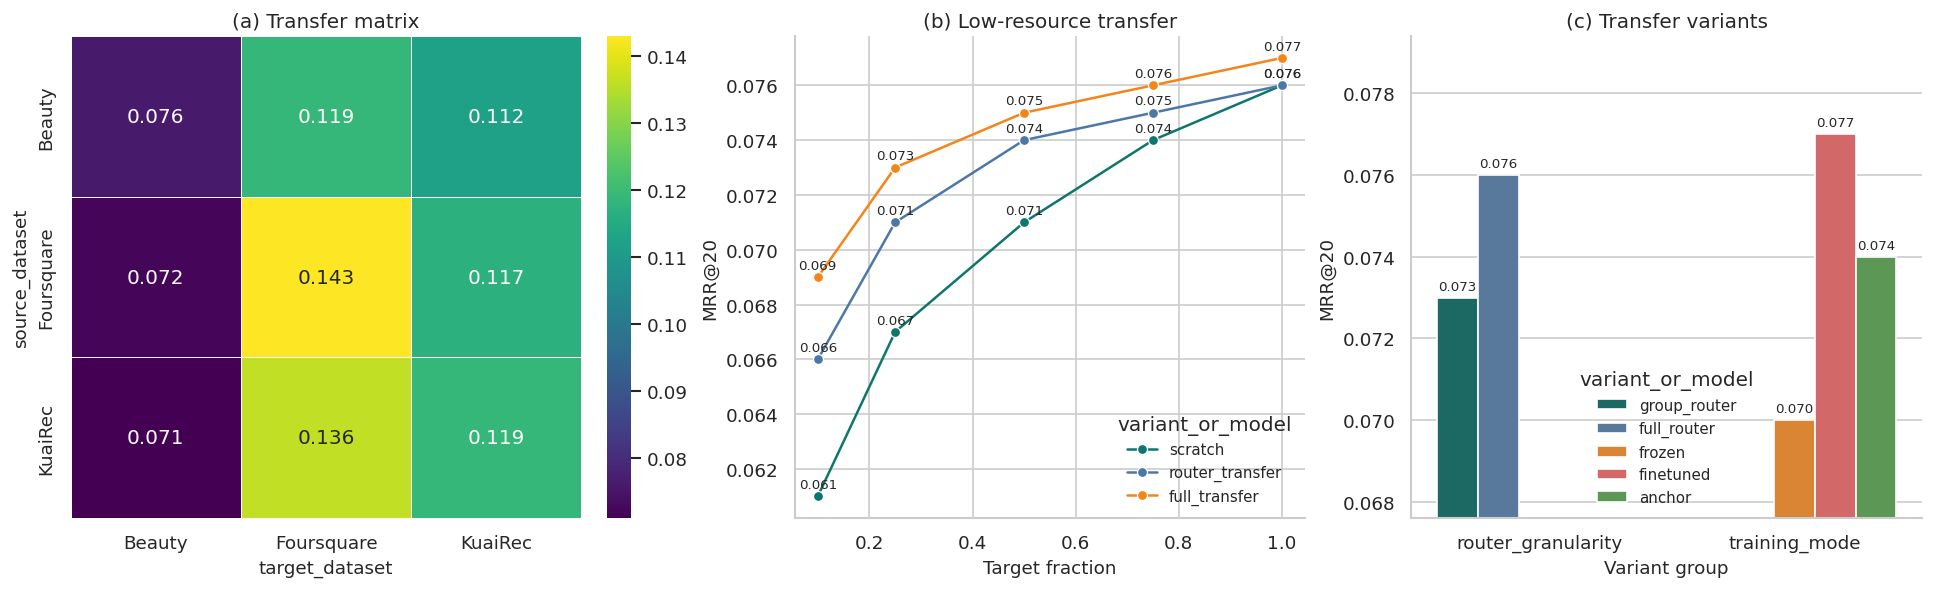

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
heatmap_from_long(matrix_df, index="source_dataset", columns="target_dataset", values="value", ax=axes[0], title="(a) Transfer matrix", cmap="viridis", fmt=".3f")
lineplot_with_markers(low_df, x="target_fraction", y="value", hue="variant_or_model", ax=axes[1], title="(b) Low-resource transfer", ylabel="MRR@20", xlabel="Target fraction", annotate_points=True)
grouped_barplot(variant_df, x="variant_group", hue="variant_or_model", y="value", ax=axes[2], title="(c) Transfer variants", ylabel="MRR@20", xlabel="Variant group")
saved_paths = export_figure(fig, "A05_transfer", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
